# Report 2 — Member Churn Risk & Retention Analysis Dashboard
Data sources: `churn_risk_summary.csv`, `churn_risk_members.csv`

**Summary columns:** `cohort_year`, `member_type`, `member_status`, `risk_tier`, `member_count`, `avg_recency_days`, `total_orders`, `total_revenue`, `revenue_at_risk`, `avg_churn_score`

**Member-level columns:** `member_id`, `member_type`, `member_status`, `cohort_year`, `registration_date`, `last_order_date`, `recency_days`, `total_orders`, `total_revenue`, `avg_order_value`, `risk_tier`, `churn_score`

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 130,
})

%matplotlib inline

## Load and clean data

In [2]:
HERE = os.getcwd()

SUM_CSV = os.path.join(HERE, "churn_risk_summary.csv")
MEM_CSV = os.path.join(HERE, "churn_risk_members.csv")

SUM_COLS = [
    "cohort_year", "member_type", "member_status", "risk_tier",
    "member_count", "avg_recency_days", "total_orders",
    "total_revenue", "revenue_at_risk", "avg_churn_score",
]
MEM_COLS = [
    "member_id", "member_type", "member_status", "cohort_year",
    "registration_date", "last_order_date", "recency_days",
    "total_orders", "total_revenue", "avg_order_value",
    "risk_tier", "churn_score",
]

df  = pd.read_csv(SUM_CSV, header=0, names=SUM_COLS)
dfm = pd.read_csv(MEM_CSV, header=0, names=MEM_COLS)

for col in ["member_count", "avg_recency_days", "total_orders",
            "total_revenue", "revenue_at_risk", "avg_churn_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["recency_days", "total_orders", "total_revenue",
            "avg_order_value", "churn_score"]:
    dfm[col] = pd.to_numeric(dfm[col], errors="coerce")

df.head()

,cohort_year,member_type,member_status,risk_tier,member_count,avg_recency_days,total_orders,total_revenue,revenue_at_risk,avg_churn_score
0,2016,VIP,ACTIVE,Medium,1,82.0,47,5060.49,2277.22,1.1
1,2016,VIP,ACTIVE,Low,1,46.0,79,8674.25,1301.14,1.0
2,2016,VIP,ACTIVE,Healthy,3,18.0,160,20857.99,0.00,1.0
3,2016,NORMAL,ACTIVE,Low,5,50.6,386,41092.92,6163.94,1.0
4,2016,NORMAL,ACTIVE,Healthy,5,15.0,254,27042.03,0.00,1.0


## Colour palettes and tier ordering

In [3]:
TIER_ORDER  = ["Churned", "Critical", "High", "Suspended",
               "Medium", "Low", "Healthy", "New - No Order"]
TIER_COLORS = {
    "Churned":       "#C0392B",
    "Critical":      "#E74C3C",
    "High":          "#E67E22",
    "Suspended":     "#9B59B6",
    "Medium":        "#F1C40F",
    "Low":           "#3498DB",
    "Healthy":       "#2ECC71",
    "New - No Order":"#95A5A6",
}
TYPE_COLORS = {"VIP": "#F5A623", "NORMAL": "#4C9BE8"}

TIER_LABELS = {
    "Churned": "Churned\n(Deactivated)",
    "Critical": "Critical\n(> 180 days)",
    "High": "High\n(91-180 days)",
    "Suspended": "Suspended\n(Account Hold)",
    "Medium": "Medium\n(61-90 days)",
    "Low": "Low\n(31-60 days)",
    "Healthy": "Healthy\n(≤ 30 days)",
    "New - No Order": "New\n(≤ 30 days)"
}

## VIZ 1 — Safe vs At-Risk Revenue by Risk Tier
### Pattern: how much revenue sits in each risk tier, and how much of it is already at risk

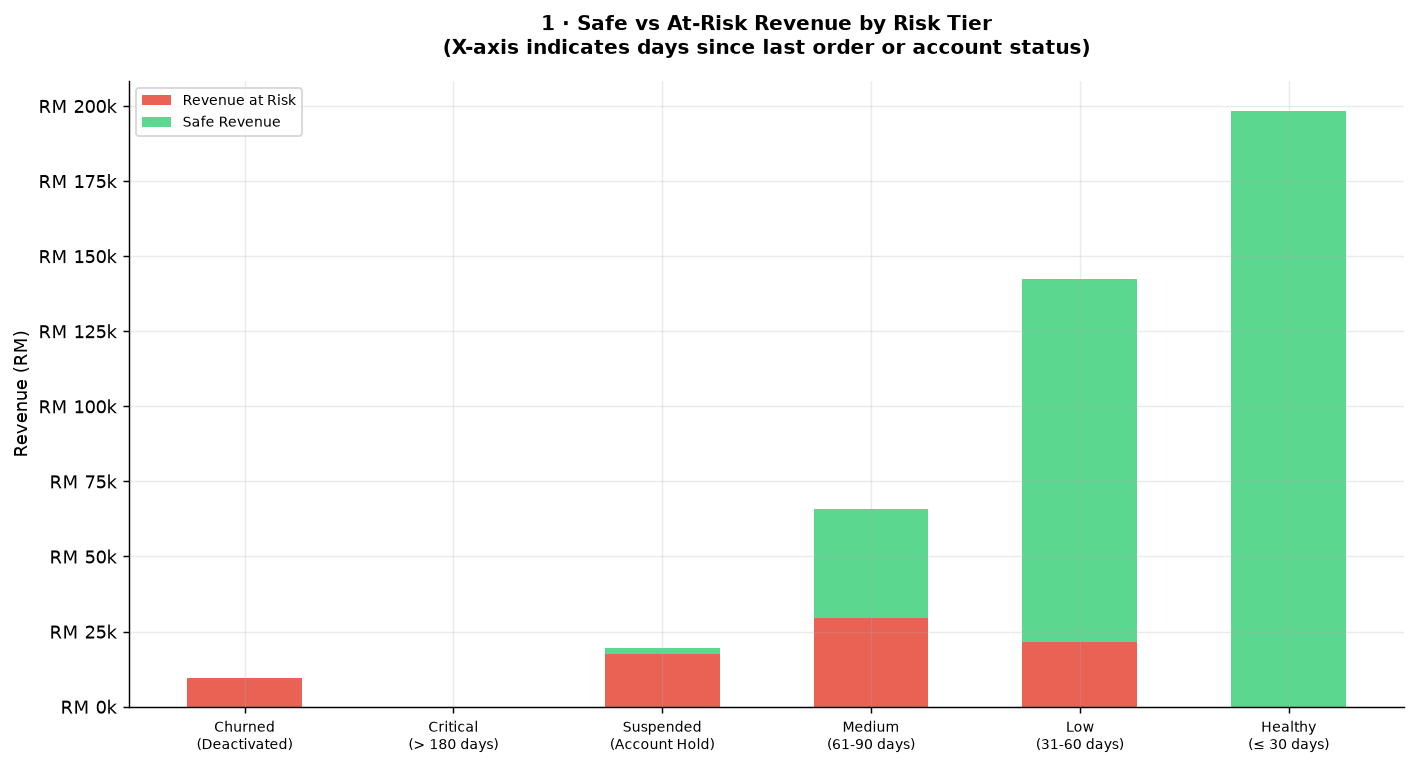

In [4]:
fig1, ax1 = plt.subplots(figsize=(11, 6))
grp1 = df.groupby("risk_tier")[["total_revenue", "revenue_at_risk"]].sum()
grp1["safe_revenue"] = grp1["total_revenue"] - grp1["revenue_at_risk"]
grp1 = grp1.reindex([t for t in TIER_ORDER if t in grp1.index])

x1 = np.arange(len(grp1))
w1 = 0.55
bars_at  = ax1.bar(x1, grp1["revenue_at_risk"], w1,
                   label="Revenue at Risk", color="#E74C3C", alpha=0.88)
bars_safe = ax1.bar(x1, grp1["safe_revenue"], w1,
                    bottom=grp1["revenue_at_risk"],
                    label="Safe Revenue", color="#2ECC71", alpha=0.78)

new_labels = [TIER_LABELS.get(t, t) for t in grp1.index]
ax1.set_xticks(x1)
ax1.set_xticklabels(new_labels, rotation=0, ha="center", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax1.set_title("1 · Safe vs At-Risk Revenue by Risk Tier\n(X-axis indicates days since last order or account status)", fontsize=11, pad=15)
ax1.set_ylabel("Revenue (RM)")
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

## VIZ 2 — Expected Revenue at Risk by Cohort Year
### Pattern: which registration cohorts carry the most revenue exposure

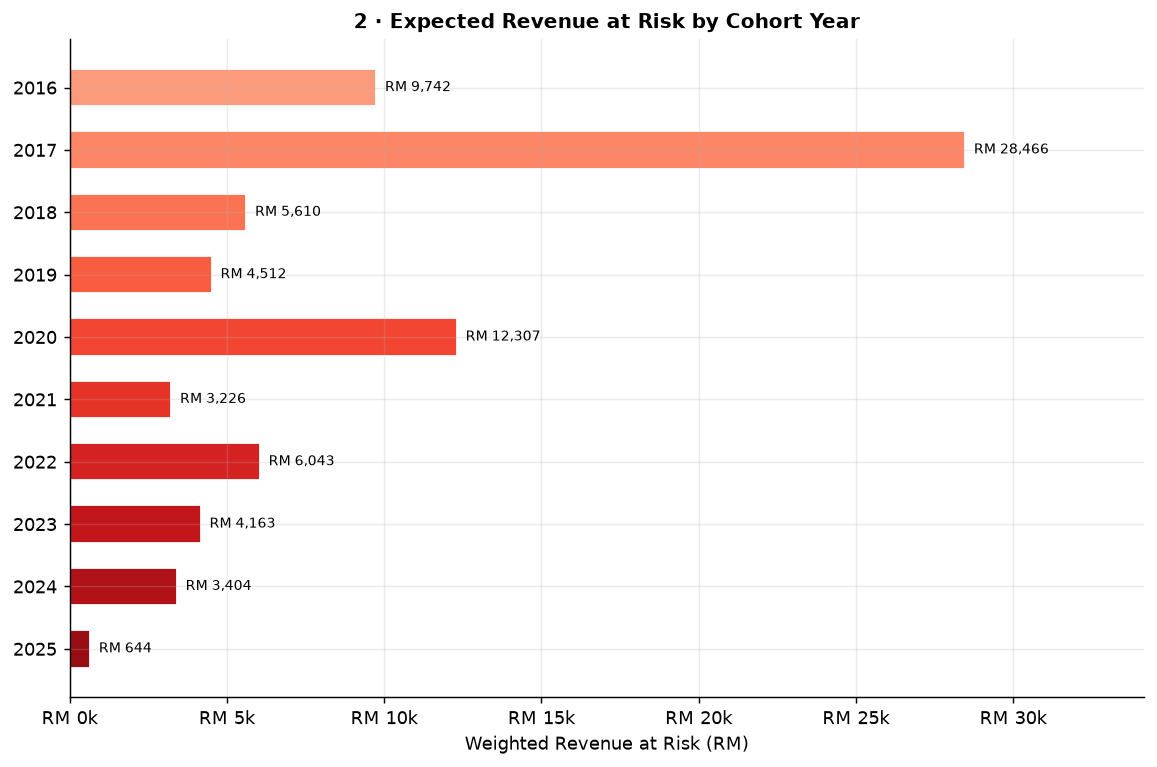

In [5]:
fig2, ax2 = plt.subplots(figsize=(9, 6))
grp2 = df.groupby("cohort_year")["revenue_at_risk"].sum().sort_index()
colors2 = plt.cm.Reds(np.linspace(0.35, 0.90, len(grp2)))
bars2 = ax2.barh(grp2.index.astype(str), grp2.values,
                 color=colors2, edgecolor="white", height=0.6)

for bar, val in zip(bars2, grp2.values):
    ax2.text(val + grp2.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"RM {val:,.0f}", va="center", fontsize=7.5)

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax2.set_title("2 · Expected Revenue at Risk by Cohort Year")
ax2.set_xlabel("Weighted Revenue at Risk (RM)")
ax2.set_xlim(0, grp2.max() * 1.20)
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

## VIZ 3 — Member Count Heatmap: Cohort Year × Risk Tier
### Pattern: where at-risk members concentrate across registration cohorts

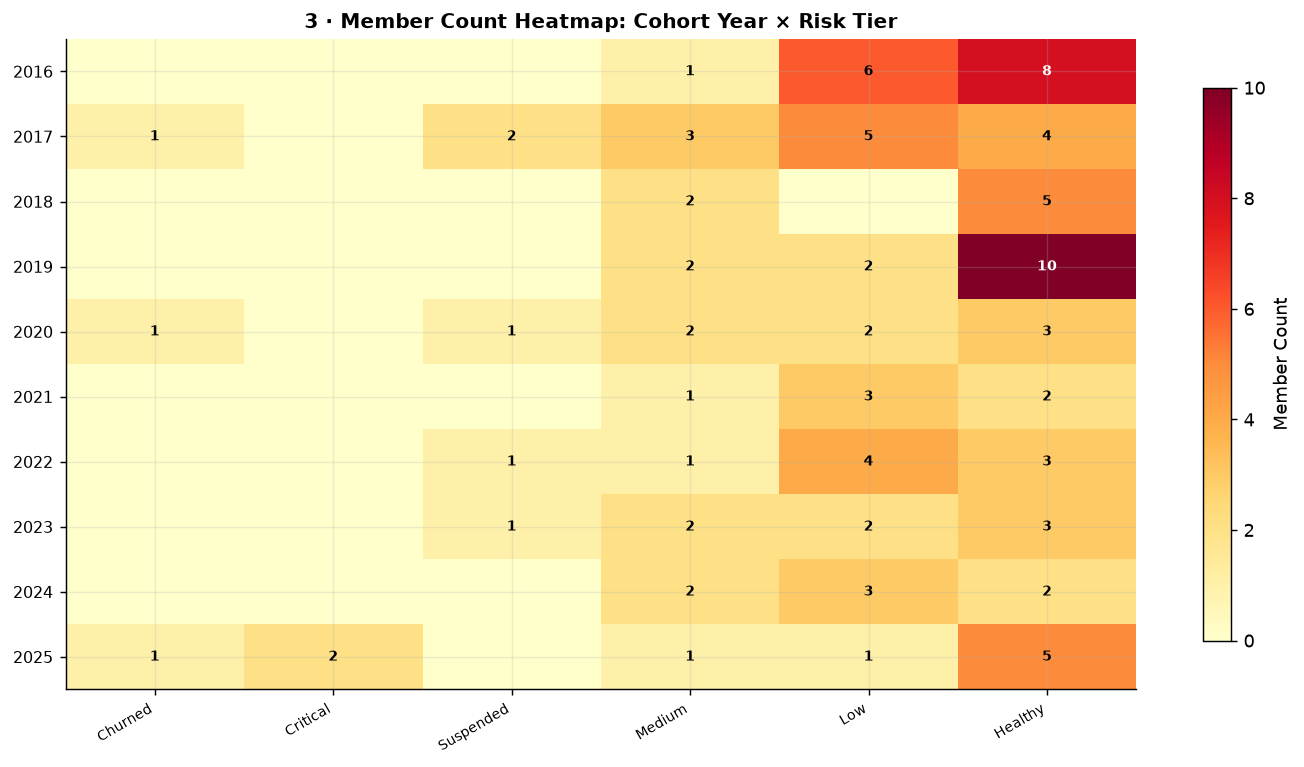

In [6]:
fig3, ax3 = plt.subplots(figsize=(11, 6))
pivot3 = df.pivot_table(
    index="cohort_year", columns="risk_tier",
    values="member_count", aggfunc="sum", fill_value=0
)
pivot3 = pivot3.reindex(columns=[t for t in TIER_ORDER if t in pivot3.columns])

im = ax3.imshow(pivot3.values, cmap="YlOrRd", aspect="auto")
ax3.set_xticks(range(len(pivot3.columns)))
ax3.set_xticklabels(pivot3.columns, rotation=30, ha="right", fontsize=8)
ax3.set_yticks(range(len(pivot3.index)))
ax3.set_yticklabels(pivot3.index.astype(str), fontsize=9)
for row in range(len(pivot3.index)):
    for col in range(len(pivot3.columns)):
        val = int(pivot3.values[row, col])
        if val > 0:
            ax3.text(col, row, str(val),
                     ha="center", va="center",
                     fontsize=8, fontweight="bold",
                     color="white" if pivot3.values[row, col] > pivot3.values.max() * 0.6 else "black")
plt.colorbar(im, ax=ax3, label="Member Count", shrink=0.85)
ax3.set_title("3 · Member Count Heatmap: Cohort Year × Risk Tier")
plt.tight_layout()
plt.show()

## VIZ 4 — Churn Score vs Revenue: Win-Back Target Quadrant
### Pattern: high-revenue members with elevated churn scores are priority win-back targets

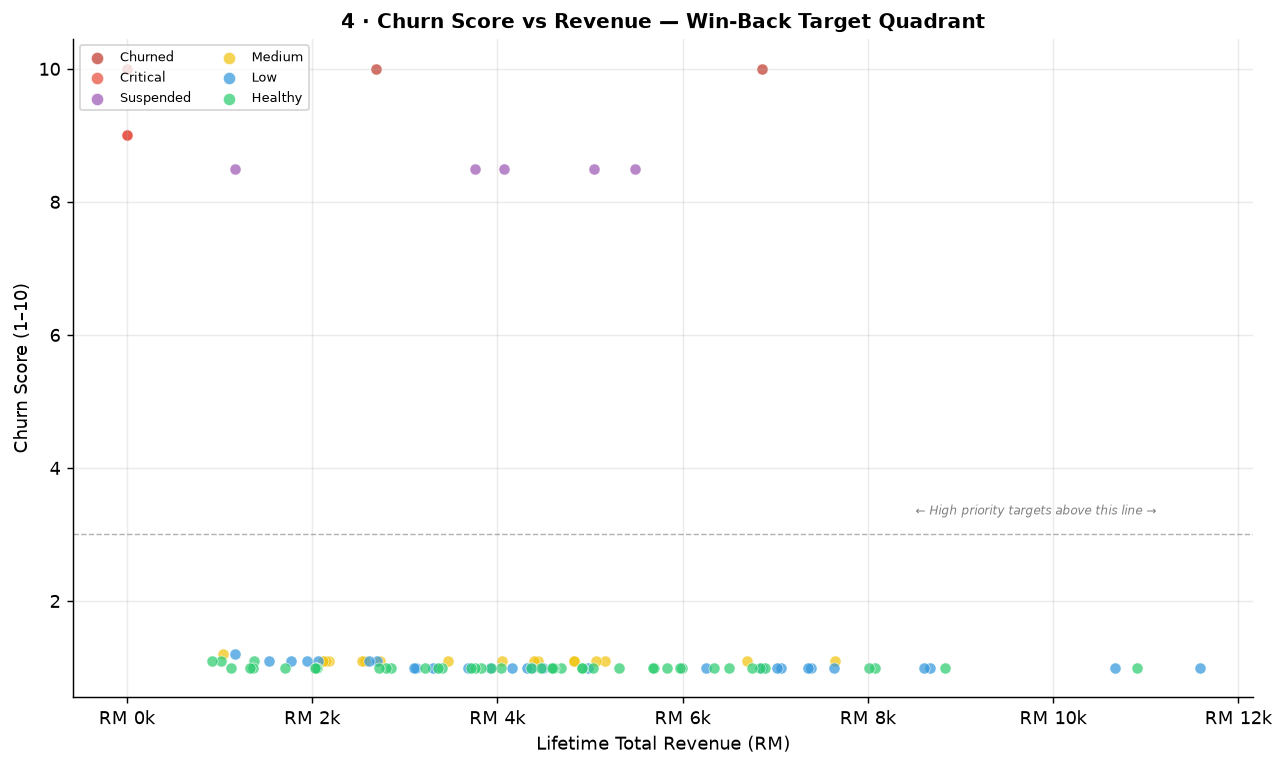

In [7]:
fig4, ax4 = plt.subplots(figsize=(10, 6))
for tier in TIER_ORDER:
    sub = dfm[dfm["risk_tier"] == tier]
    if sub.empty:
        continue
    ax4.scatter(
        sub["total_revenue"], sub["churn_score"],
        c=TIER_COLORS.get(tier, "grey"),
        label=tier, alpha=0.72, s=38, edgecolors="white", linewidths=0.4
    )

ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax4.set_xlabel("Lifetime Total Revenue (RM)")
ax4.set_ylabel("Churn Score (1–10)")
ax4.set_title("4 · Churn Score vs Revenue — Win-Back Target Quadrant")
ax4.axhline(y=3.0, color="grey", lw=0.8, ls="--", alpha=0.6)
ax4.text(ax4.get_xlim()[1] * 0.7, 3.3,
         "← High priority targets above this line →",
         fontsize=6.5, color="grey", style="italic")
ax4.legend(fontsize=7, markerscale=1.1, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

## VIZ 5 — VIP vs NORMAL Member Count by Risk Tier
### Pattern: does membership tier protect against churn risk

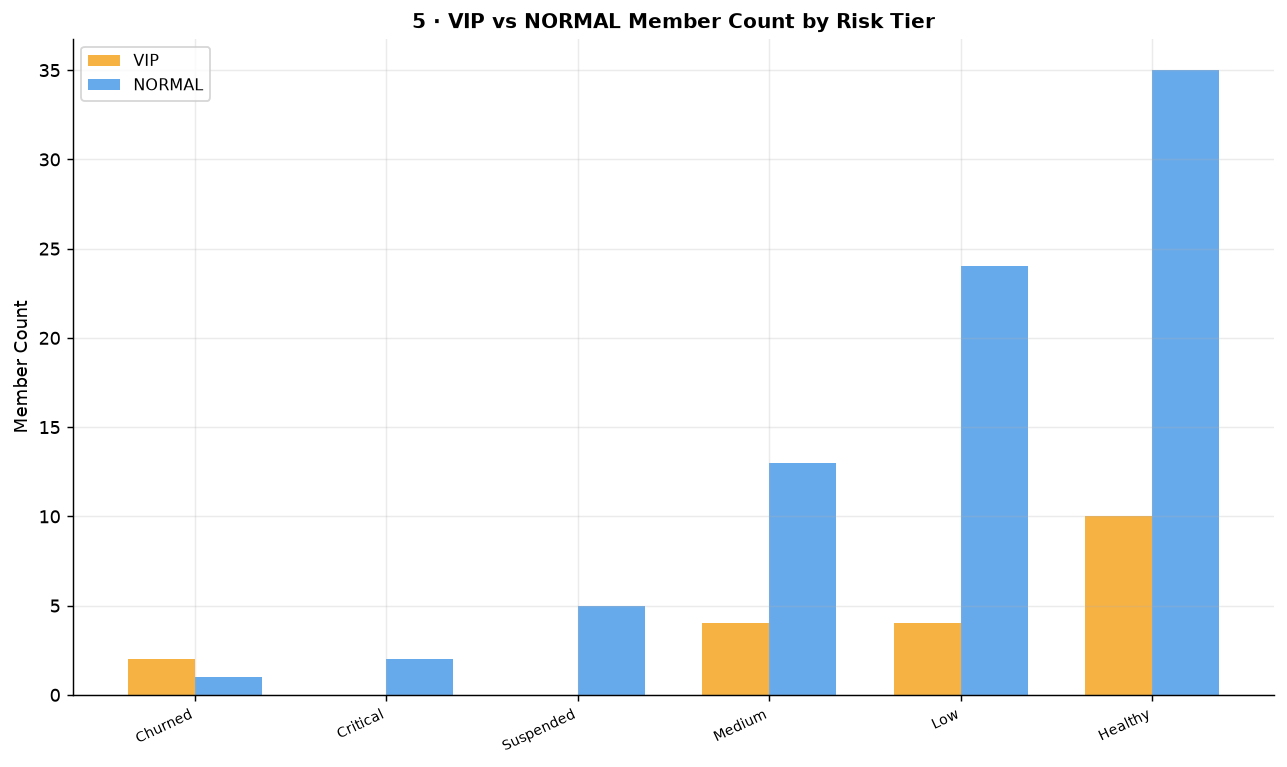

In [8]:
fig5, ax5 = plt.subplots(figsize=(10, 6))
grp5 = df.groupby(["risk_tier", "member_type"])["member_count"].sum().unstack(fill_value=0)
grp5 = grp5.reindex([t for t in TIER_ORDER if t in grp5.index])
x5   = np.arange(len(grp5))
w5   = 0.35
for i, mtype in enumerate(["VIP", "NORMAL"]):
    if mtype in grp5.columns:
        ax5.bar(x5 + i * w5, grp5[mtype], w5,
                label=mtype, color=TYPE_COLORS[mtype], alpha=0.85)

ax5.set_xticks(x5 + w5 / 2)
ax5.set_xticklabels(grp5.index, rotation=25, ha="right", fontsize=8)
ax5.set_ylabel("Member Count")
ax5.set_title("5 · VIP vs NORMAL Member Count by Risk Tier")
ax5.legend(fontsize=9)
plt.tight_layout()
plt.show()

## VIZ 6 — Revenue Share by Risk Tier per Cohort Year (100% Stacked)
### Pattern: how the risk-tier composition of cohort revenue shifts over time

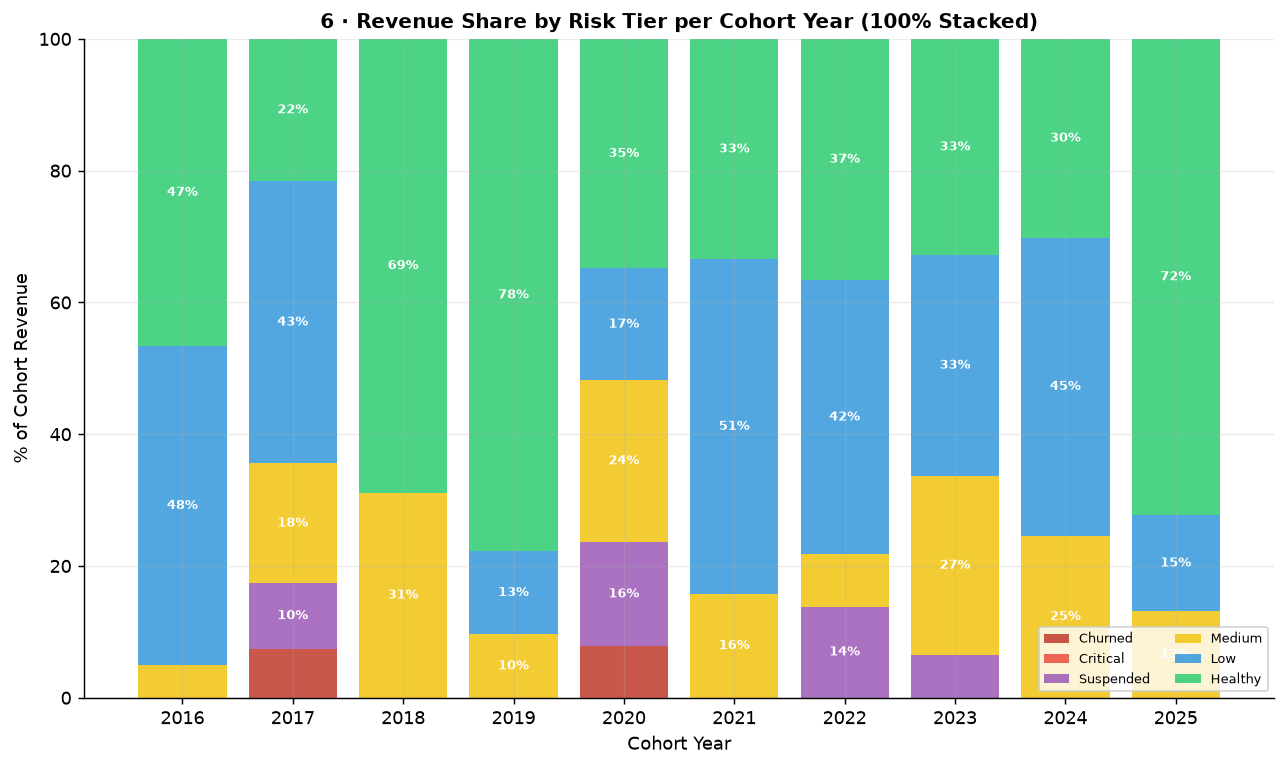

In [9]:
fig6, ax6 = plt.subplots(figsize=(10, 6))
pivot6 = df.pivot_table(
    index="cohort_year", columns="risk_tier",
    values="total_revenue", aggfunc="sum", fill_value=0
)
pivot6 = pivot6.reindex(columns=[t for t in TIER_ORDER if t in pivot6.columns])
pivot6_pct = pivot6.div(pivot6.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(pivot6_pct))
for tier in pivot6_pct.columns:
    vals = pivot6_pct[tier].values
    ax6.bar(pivot6_pct.index.astype(str), vals, bottom=bottom,
            label=tier, color=TIER_COLORS.get(tier, "grey"), alpha=0.85)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax6.text(j, b + v / 2, f"{v:.0f}%",
                     ha="center", va="center", fontsize=7, fontweight="bold",
                     color="white")
    bottom += vals

ax6.set_ylim(0, 100)
ax6.set_ylabel("% of Cohort Revenue")
ax6.set_xlabel("Cohort Year")
ax6.set_title("6 · Revenue Share by Risk Tier per Cohort Year (100% Stacked)")
ax6.legend(fontsize=7, loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

## Combined dashboard (all 6 visualisations) and save to file

Dashboard saved: c:\Users\KTYJ\Documents\TARUMT\NEW ERA\WAREHOUSE\Data-warehouse\tjy\churn_risk_dashboard_subplots.png


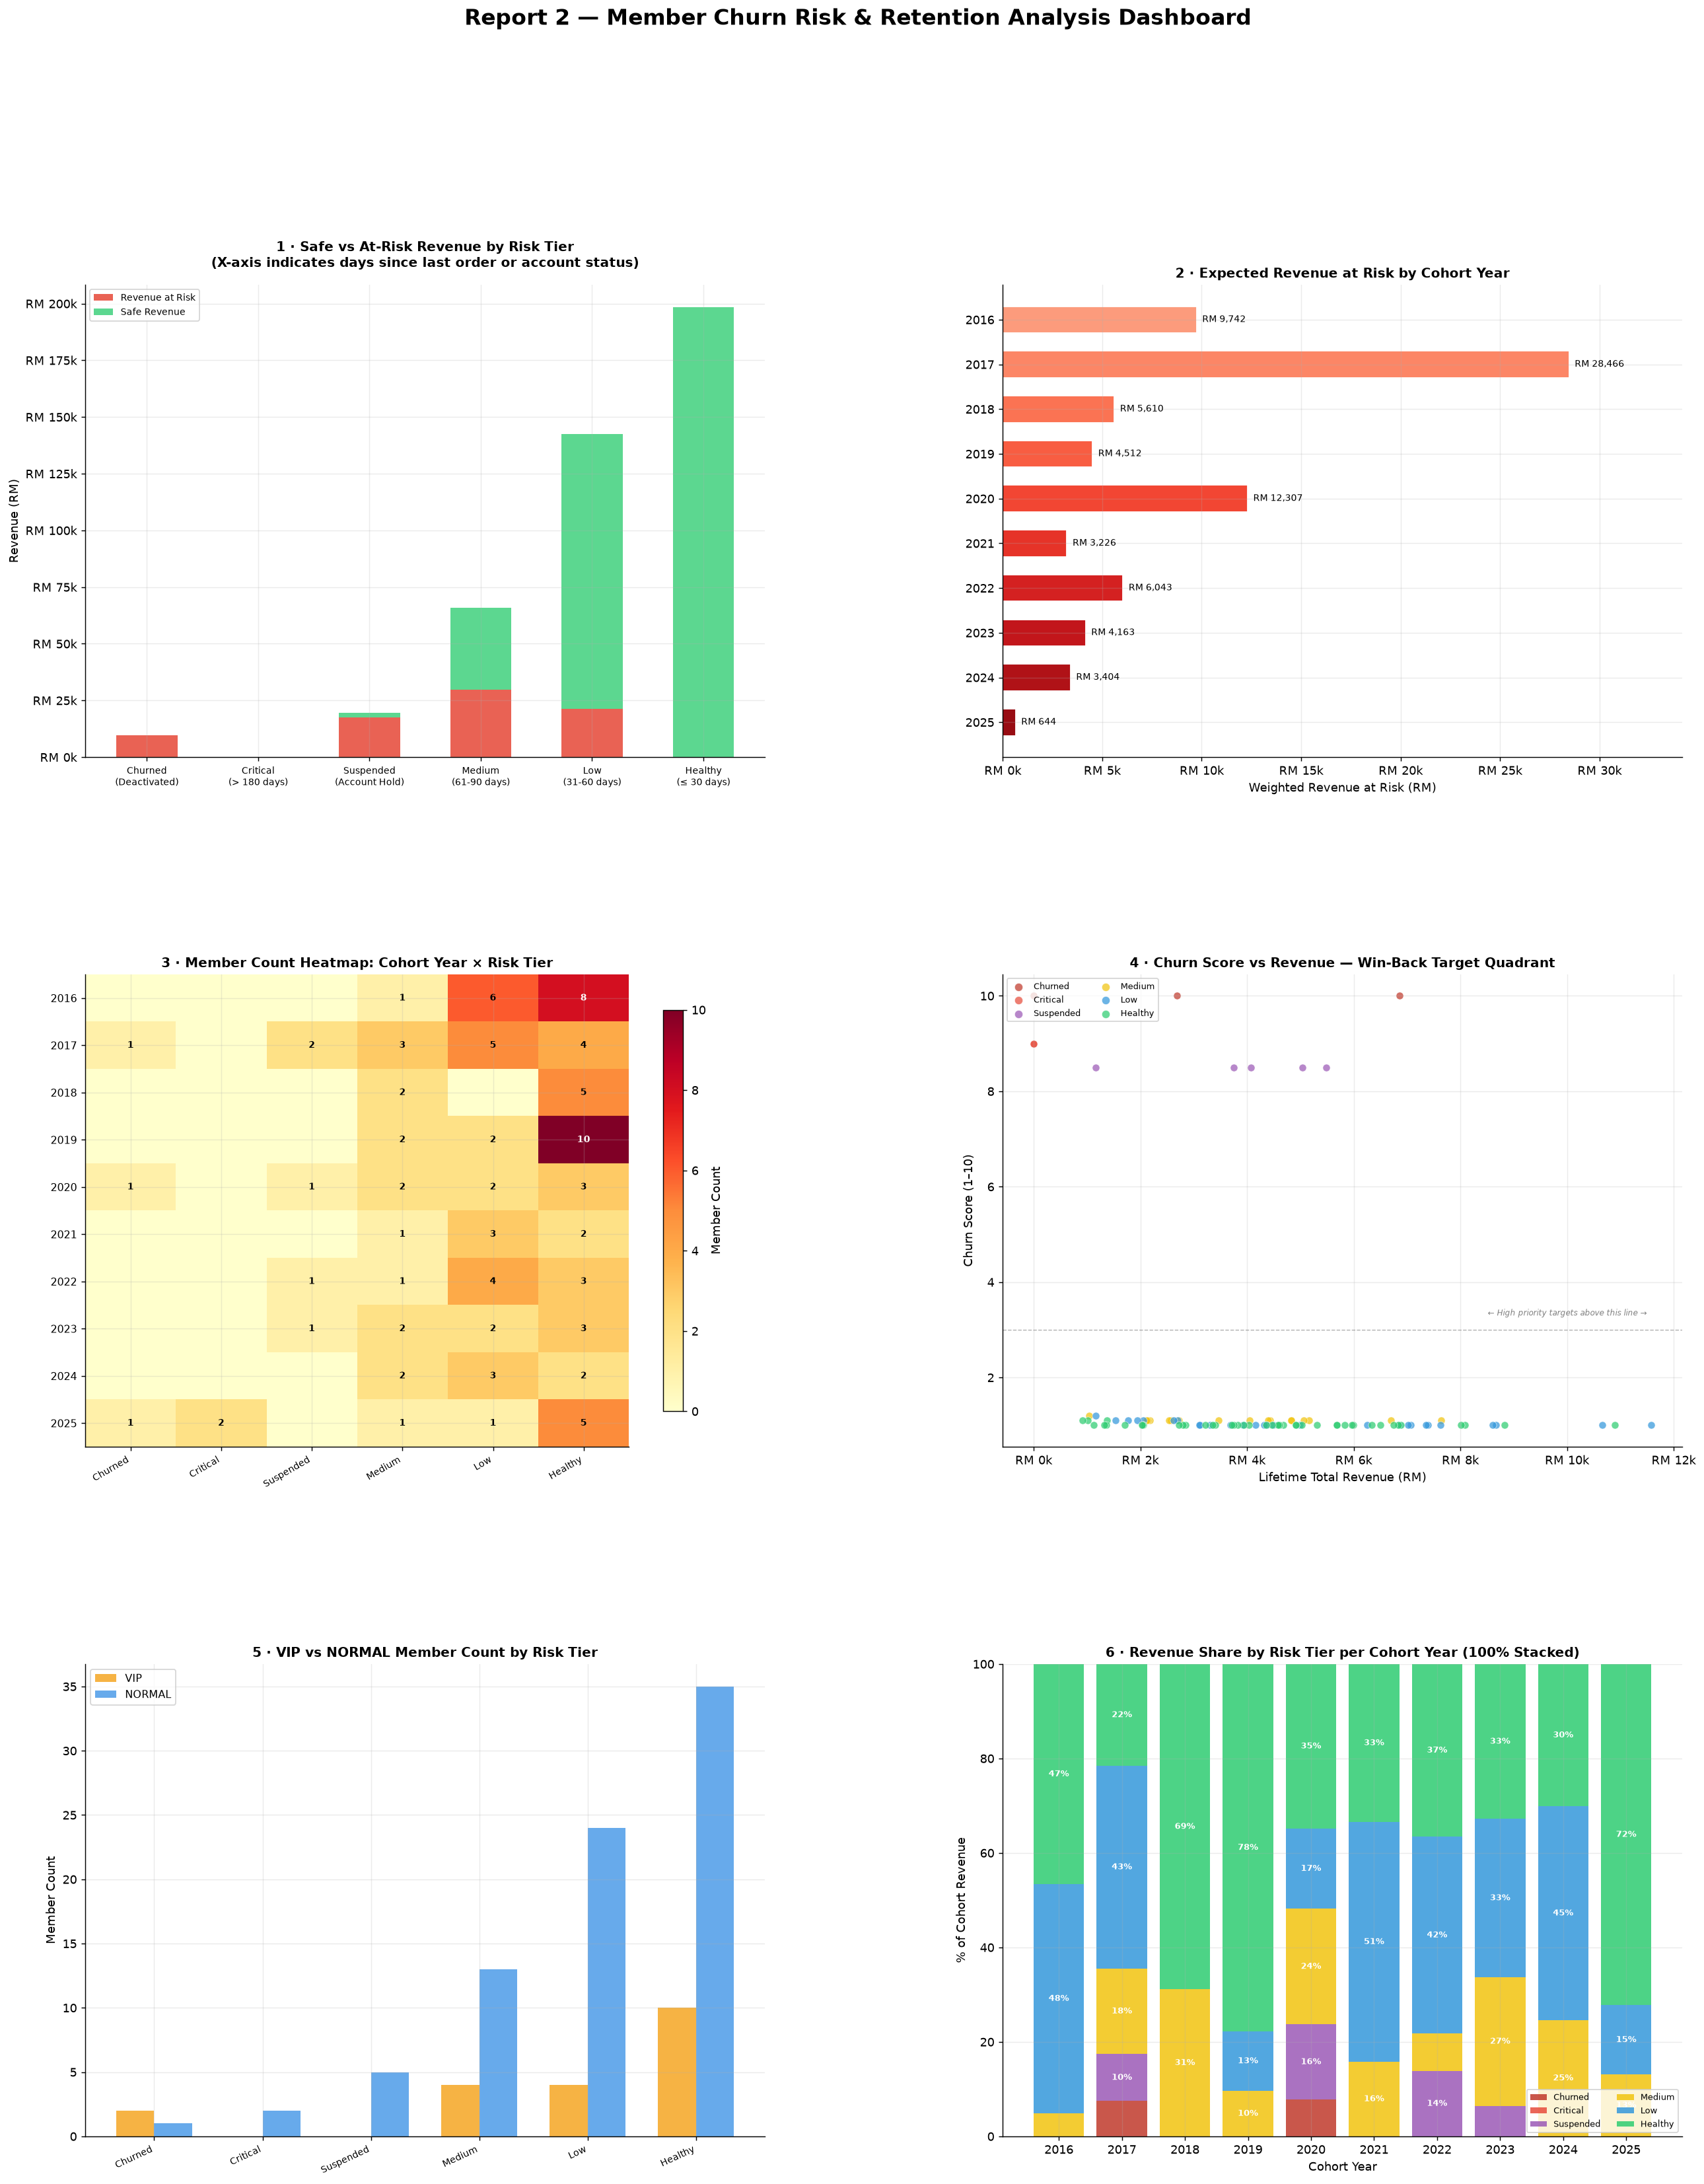

In [10]:
fig = plt.figure(figsize=(24, 28))
fig.suptitle(
    "Report 2 — Member Churn Risk & Retention Analysis Dashboard",
    fontsize=18, fontweight="bold", y=0.995
)
gs = fig.add_gridspec(3, 2, hspace=0.46, wspace=0.35)

# VIZ 1
ax1 = fig.add_subplot(gs[0, 0])
grp1 = df.groupby("risk_tier")[["total_revenue", "revenue_at_risk"]].sum()
grp1["safe_revenue"] = grp1["total_revenue"] - grp1["revenue_at_risk"]
grp1 = grp1.reindex([t for t in TIER_ORDER if t in grp1.index])
x1 = np.arange(len(grp1))
w1 = 0.55
ax1.bar(x1, grp1["revenue_at_risk"], w1, label="Revenue at Risk", color="#E74C3C", alpha=0.88)
ax1.bar(x1, grp1["safe_revenue"], w1, bottom=grp1["revenue_at_risk"],
        label="Safe Revenue", color="#2ECC71", alpha=0.78)
new_labels = [TIER_LABELS.get(t, t) for t in grp1.index]
ax1.set_xticks(x1)
ax1.set_xticklabels(new_labels, rotation=0, ha="center", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax1.set_title("1 · Safe vs At-Risk Revenue by Risk Tier\n(X-axis indicates days since last order or account status)", fontsize=11, pad=15)
ax1.set_ylabel("Revenue (RM)")
ax1.legend(fontsize=8)

# VIZ 2
ax2 = fig.add_subplot(gs[0, 1])
grp2 = df.groupby("cohort_year")["revenue_at_risk"].sum().sort_index()
colors2 = plt.cm.Reds(np.linspace(0.35, 0.90, len(grp2)))
bars2 = ax2.barh(grp2.index.astype(str), grp2.values, color=colors2, edgecolor="white", height=0.6)
for bar, val in zip(bars2, grp2.values):
    ax2.text(val + grp2.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"RM {val:,.0f}", va="center", fontsize=7.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax2.set_title("2 · Expected Revenue at Risk by Cohort Year")
ax2.set_xlabel("Weighted Revenue at Risk (RM)")
ax2.set_xlim(0, grp2.max() * 1.20)
ax2.invert_yaxis()

# VIZ 3
ax3 = fig.add_subplot(gs[1, 0])
pivot3 = df.pivot_table(index="cohort_year", columns="risk_tier", values="member_count", aggfunc="sum", fill_value=0)
pivot3 = pivot3.reindex(columns=[t for t in TIER_ORDER if t in pivot3.columns])
im = ax3.imshow(pivot3.values, cmap="YlOrRd", aspect="auto")
ax3.set_xticks(range(len(pivot3.columns)))
ax3.set_xticklabels(pivot3.columns, rotation=30, ha="right", fontsize=8)
ax3.set_yticks(range(len(pivot3.index)))
ax3.set_yticklabels(pivot3.index.astype(str), fontsize=9)
for row in range(len(pivot3.index)):
    for col in range(len(pivot3.columns)):
        val = int(pivot3.values[row, col])
        if val > 0:
            ax3.text(col, row, str(val), ha="center", va="center", fontsize=8, fontweight="bold",
                     color="white" if pivot3.values[row, col] > pivot3.values.max() * 0.6 else "black")
plt.colorbar(im, ax=ax3, label="Member Count", shrink=0.85)
ax3.set_title("3 · Member Count Heatmap: Cohort Year × Risk Tier")

# VIZ 4
ax4 = fig.add_subplot(gs[1, 1])
for tier in TIER_ORDER:
    sub = dfm[dfm["risk_tier"] == tier]
    if sub.empty:
        continue
    ax4.scatter(sub["total_revenue"], sub["churn_score"], c=TIER_COLORS.get(tier, "grey"),
                label=tier, alpha=0.72, s=38, edgecolors="white", linewidths=0.4)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax4.set_xlabel("Lifetime Total Revenue (RM)")
ax4.set_ylabel("Churn Score (1–10)")
ax4.set_title("4 · Churn Score vs Revenue — Win-Back Target Quadrant")
ax4.axhline(y=3.0, color="grey", lw=0.8, ls="--", alpha=0.6)
ax4.text(ax4.get_xlim()[1] * 0.7, 3.3, "← High priority targets above this line →",
         fontsize=6.5, color="grey", style="italic")
ax4.legend(fontsize=7, markerscale=1.1, ncol=2, loc="upper left")

# VIZ 5
ax5 = fig.add_subplot(gs[2, 0])
grp5 = df.groupby(["risk_tier", "member_type"])["member_count"].sum().unstack(fill_value=0)
grp5 = grp5.reindex([t for t in TIER_ORDER if t in grp5.index])
x5 = np.arange(len(grp5))
w5 = 0.35
for i, mtype in enumerate(["VIP", "NORMAL"]):
    if mtype in grp5.columns:
        ax5.bar(x5 + i * w5, grp5[mtype], w5, label=mtype, color=TYPE_COLORS[mtype], alpha=0.85)
ax5.set_xticks(x5 + w5 / 2)
ax5.set_xticklabels(grp5.index, rotation=25, ha="right", fontsize=8)
ax5.set_ylabel("Member Count")
ax5.set_title("5 · VIP vs NORMAL Member Count by Risk Tier")
ax5.legend(fontsize=9)

# VIZ 6
ax6 = fig.add_subplot(gs[2, 1])
pivot6 = df.pivot_table(index="cohort_year", columns="risk_tier", values="total_revenue", aggfunc="sum", fill_value=0)
pivot6 = pivot6.reindex(columns=[t for t in TIER_ORDER if t in pivot6.columns])
pivot6_pct = pivot6.div(pivot6.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(pivot6_pct))
for tier in pivot6_pct.columns:
    vals = pivot6_pct[tier].values
    ax6.bar(pivot6_pct.index.astype(str), vals, bottom=bottom, label=tier,
            color=TIER_COLORS.get(tier, "grey"), alpha=0.85)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax6.text(j, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=7,
                     fontweight="bold", color="white")
    bottom += vals
ax6.set_ylim(0, 100)
ax6.set_ylabel("% of Cohort Revenue")
ax6.set_xlabel("Cohort Year")
ax6.set_title("6 · Revenue Share by Risk Tier per Cohort Year (100% Stacked)")
ax6.legend(fontsize=7, loc="lower right", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.987])
out = os.path.join(HERE, "churn_risk_dashboard_subplots.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Dashboard saved: {out}")
plt.show()